I selected the Stroke Prediction dataset because it contains missing values and an imbalanced target class. The target variable is stroke, where most patients did not experience stroke and only a small number did. Therefore, this dataset is suitable for advanced classification because it requires missing value treatment and class imbalance handling.

Import necessary libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import and display the dataset. find other dataset that has missing value and imbalanced class (target)

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/fmspecial/Stroke_Prediction/refs/heads/master/Stroke_dataset.csv')
df.head()

,Unnamed: 0,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,1,67.0,0,1,1,Private,1,228.69,36.600000,formerly smoked,1
1,1,0,61.0,0,0,1,Self-employed,0,202.21,28.893237,never smoked,1
2,2,1,80.0,0,1,1,Private,0,105.92,32.500000,never smoked,1
3,3,0,49.0,0,0,1,Private,1,171.23,34.400000,smokes,1
4,4,0,79.0,1,0,1,Self-employed,0,174.12,24.000000,never smoked,1


In [ ]:
df.shape #5110 rows of data, 12 columns

(5110, 12)

Check total missing value

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


METHOD 1: simply drop row of missing value

In [ ]:
df_drop_na = df.dropna()

In [ ]:
df_drop_na.isnull().sum()

,0
Unnamed: 0,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
df_drop_na.shape

(5110, 12)

do classification

In [ ]:
X = df_drop_na.iloc[:, 1:-1] #input
y = df_drop_na.iloc[:, -1] #target

In [ ]:
X = pd.get_dummies(X) #text columns into numeric format

Model Training- Split train/test data

In [ ]:
from sklearn.model_selection import train_test_split #test_size=0.3, 70% training, 30% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

Decision Tree Classification

In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

Prediction

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

result_acc = accuracy_score(y_test, y_pred)
print("ACCURACY:", result_acc)

result_conf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", result_conf)

ACCURACY: 0.9230267449445532
Confusion Matrix:
 [[1400   57]
 [  61   15]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1457
           1       0.21      0.20      0.20        76

    accuracy                           0.92      1533
   macro avg       0.58      0.58      0.58      1533
weighted avg       0.92      0.92      0.92      1533



METHOD 2: data imputation

KNNImputer was used to handle missing values by estimating missing entries based on the nearest neighboring samples. Unlike dropping rows, data imputation preserves more observations and may improve model performance. After imputing missing values, a Decision Tree classifier was trained and evaluated on the processed dataset.

In [ ]:
from sklearn.impute import KNNImputer
df_encoded = pd.get_dummies(df)

In [ ]:
imputer = KNNImputer(
    n_neighbors=5,
    weights='uniform'
) # 5 nearest rows to estimate missing values.

In [ ]:
df_impute = pd.DataFrame(
    imputer.fit_transform(df_encoded),
    columns=df_encoded.columns
) # created new variable

In [ ]:
df_impute.isnull().sum()

,0
Unnamed: 0,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
Residence_type,0
avg_glucose_level,0
bmi,0
stroke,0


Do classification

In [ ]:
X = df_impute.drop('stroke', axis=1)
y = df_impute['stroke']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix

result_acc = accuracy_score(y_test, y_pred)
print("ACCURACY:", result_acc)

result_conf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", result_conf)

ACCURACY: 0.9986953685583823
Confusion Matrix:
 [[1457    0]
 [   2   74]]


Handling imbalanced classes

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


class 0 dominates
class 1 is minority

This is imbalanced classification.

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

Synthetic Minority Oversampling Technique

It creates synthetic/artificial samples for the minority class by new similar data points.

In [ ]:
X = df_impute.iloc[:, 1:-1]
y = df_impute.iloc[:, -1]

In [ ]:
oversample = SMOTE()

X, y = oversample.fit_resample(X, y)

In [ ]:
y.value_counts() #checking the class balance again

,count
smoking_status_smokes,
0.0,4321
1.0,4321


do classification

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)
from sklearn import tree

model = tree.DecisionTreeClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

result_acc = accuracy_score(y_test, y_pred)
print("ACCURACY:", result_acc)

result_conf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", result_conf)

print(classification_report(y_test, y_pred))

ACCURACY: 1.0
Confusion Matrix:
 [[1339    0]
 [   0 1254]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1339
         1.0       1.00      1.00      1.00      1254

    accuracy                           1.00      2593
   macro avg       1.00      1.00      1.00      2593
weighted avg       1.00      1.00      1.00      2593



Visualization

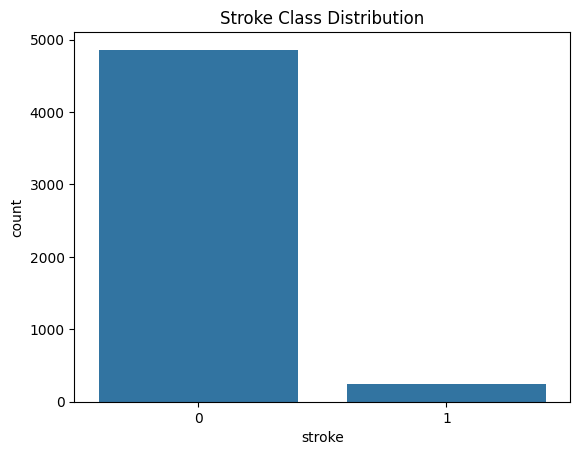

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['stroke'])

plt.title('Stroke Class Distribution')

plt.show()

The dataset contains an imbalanced target class where stroke cases are significantly fewer than non-stroke cases. To address this issue, SMOTE was applied to generate synthetic samples for the minority class. so this improve classification performance and reduces model bias toward the majority class.